# 05. 메시지 삭제: RemoveMessage와 자동 삭제 전략

> 긴 대화는 컨텍스트 윈도우를 갉아먹어요. `RemoveMessage` 와 자동 삭제 전략으로 대화 이력을 안전하게 줄이는 기법을 정리해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `RemoveMessage` 수정자의 역할과 작동 원리를 설명할 수 있어요
2. `update_state()`를 사용해 외부에서 메시지를 수동으로 삭제할 수 있어요
3. `delete_messages` 노드를 그래프에 추가해 대화 이력을 자동으로 관리할 수 있어요
4. 메시지 개수 제한 전략으로 LLM 컨텍스트 윈도우와 토큰 비용을 관리할 수 있어요

## 사전 지식

- Part 02: `MessagesState`, `add_messages` reducer, `MemorySaver`로 체크포인팅
- Part 02: `get_state()`, `update_state()`로 그래프 상태 조회 및 수정
- Part 04: 체크포인트 복원력과 상태 이력 관리 (`04-Durable-Execution.ipynb`)

## 이전 노트북 연결

앞서 `04-Durable-Execution.ipynb`에서 체크포인트가 대화 이력을 누적 저장하는 방식을 배웠어요. 그런데 대화가 길어질수록 메시지가 계속 쌓이면 두 가지 문제가 생겨요: LLM 컨텍스트 윈도우 초과와 토큰 비용 증가. 이번 노트북에서는 이 문제를 해결하는 **메시지 삭제** 기법을 배울게요.

## RemoveMessage란?

`RemoveMessage`는 LangGraph에서 제공하는 특수 수정자(modifier)예요. 메시지 목록에서 특정 메시지를 **ID 기반으로 삭제**할 때 사용해요.

### 왜 메시지를 삭제해야 하나요?

대화가 계속되면 메시지가 쌓여요. 마치 책상 위에 서류가 쌓이는 것처럼요. 서류가 너무 많아지면 책상이 넘치죠(컨텍스트 윈도우 초과). 또한 LLM에게 모든 서류를 읽게 하면 시간도 오래 걸리고 비용도 많이 들어요(토큰 비용 증가). 그래서 오래된 서류는 정리하고 중요한 것만 남기는 거예요.

### 작동 원리

| 구성 요소 | 역할 | 특징 |
|----------|------|------|
| `RemoveMessage(id=...)` | 삭제 대상 지정 | 메시지 ID만 있으면 됨 |
| `add_messages` reducer | 실제 삭제 처리 | `RemoveMessage`를 인식하고 제거 |
| `MessagesState` | 기본 상태 타입 | `add_messages` reducer가 내장됨 |
| `update_state()` | 외부에서 상태 수정 | 그래프 외부에서 직접 호출 |

> 🔑 **핵심 개념**: `RemoveMessage`는 메시지를 직접 삭제하지 않아요. 대신 "이 ID의 메시지를 삭제하라"는 **신호**를 reducer에 보내요. `add_messages` reducer가 이 신호를 받아 실제로 상태에서 해당 메시지를 제거해요.

### 두 가지 삭제 방식

```mermaid
flowchart TB
    subgraph M ["수동 삭제 (Manual Delete)"]
        direction LR
        M1["get_state()로<br/>메시지 조회"]:::process
        M2["RemoveMessage<br/>(id=msg.id)"]:::process
        M3["update_state()<br/>호출"]:::process
        M4["get_state()로<br/>결과 확인"]:::output
        M1 --> M2 --> M3 --> M4
    end

    subgraph A ["자동 삭제 (Auto Delete)"]
        direction TB
        A1["agent 노드 실행"]:::input
        A2{"도구 호출 있음?"}:::process
        A3["action 노드 실행"]:::process
        A4["delete_messages 노드<br/>오래된 메시지 정리"]:::process
        A5["END"]:::output
        A1 --> A2
        A2 -->|예| A3
        A3 --> A1
        A2 -->|아니오| A4
        A4 --> A5
    end

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
```

| 방식 | 사용 시점 | 장점 | 단점 |
|------|----------|------|------|
| **수동 삭제** | 민감 정보 제거, 디버깅 | 정밀한 타겟팅 | 매번 코드 실행 필요 |
| **자동 삭제** | 프로덕션 운영, 일상 관리 | 자동화, 일관성 | 중요 메시지 오삭제 위험 |

> 🎯 **강의 포인트**: 수동 삭제는 특정 메시지를 정밀하게 제거할 때 유용하고, 자동 삭제는 프로덕션 환경에서 메시지 개수를 지속적으로 관리할 때 사용해요. 두 방식 모두 `RemoveMessage`를 핵심 메커니즘으로 사용해요.

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 불러와요
from dotenv import load_dotenv
load_dotenv()

# 환경 변수 로드 완료

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택)
# ---------------------------------------------------
# LangSmith 프로젝트에서 메시지 삭제 흐름을 시각적으로 추적할 수 있어요
import os

# API 키가 있는 경우 아래 주석을 해제하세요
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-DeleteMessages"

# 설정 완료

## 1. 기본 에이전트 그래프 구축

메시지 삭제를 테스트하기 위해 먼저 기본 에이전트 그래프를 만들어요. `MemorySaver` 체크포인터를 사용해 대화 이력을 축적하고, 거기에 `RemoveMessage`를 적용할 거예요.

> 🔑 **핵심 개념**: `MessagesState`는 내부에 `messages` 키와 `add_messages` reducer를 가지고 있어요. 이 reducer가 `RemoveMessage` 수정자를 이해하고 처리해요. `TypedDict`에 직접 `Annotated[list, add_messages]`를 정의해도 동일하게 작동해요.

> 💡 **실무 팁**: `RemoveMessage`는 `langchain_core.messages`에서 임포트해요. `add_messages` reducer와 함께 사용할 때만 제대로 작동하며, 일반 리스트에는 사용할 수 없어요.

In [3]:
# ---------------------------------------------------
# 필요한 모듈 임포트 및 기본 그래프 구성
# ---------------------------------------------------
# LangGraph 핵심 컴포넌트를 가져와요
from typing import Literal

from langchain_core.tools import tool          # 도구 데코레이터
from langchain_core.messages import HumanMessage  # 사람의 메시지 타입
from langchain.chat_models import init_chat_model  # V1 모델 초기화
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode

# 체크포인트를 메모리에 저장해요 (대화 이력 누적)
memory = MemorySaver()


# 웹 검색을 흉내 내는 더미 도구예요
@tool
def search(query: str) -> str:
    """Call to surf on the web."""
    # 실제 검색 대신 고정된 응답을 반환해요 (테스트용)
    return f"'{query}'에 대한 검색 결과: LangGraph는 상태 기반 멀티 에이전트 프레임워크예요."


# 도구 목록과 도구 노드를 만들어요
tools = [search]
tool_node = ToolNode(tools)  # 도구를 자동으로 실행하는 노드

# 기본 모델: gpt-4o-mini (비용 효율적)
# 다른 모델: "anthropic:claude-sonnet-4-5", "google_genai:gemini-2.0-flash"
model = init_chat_model("openai:gpt-4o-mini")
bound_model = model.bind_tools(tools)  # 도구를 모델에 바인딩해요


def should_continue(state: MessagesState) -> Literal["tool", "__end__"]:
    """마지막 메시지에 도구 호출이 있으면 tool 노드로, 없으면 END로 가요"""
    messages = state["messages"]
    # 메시지가 없는 경우 방어적 처리
    if not messages:
        return END
    last_message = messages[-1]
    if not last_message.tool_calls:
        return END  # 도구 호출 없음: 대화 종료
    return "tool"  # 도구 호출 있음: 도구 실행


def call_model(state: MessagesState):
    """현재 메시지 목록으로 LLM을 호출하고 응답을 추가해요"""
    response = bound_model.invoke(state["messages"])
    # 반환값은 자동으로 messages에 추가(append)돼요 (add_messages reducer)
    return {"messages": response}


# StateGraph: MessagesState를 상태 스키마로 사용해요
workflow = StateGraph(MessagesState)

# 노드 등록: 에이전트(LLM 호출)와 도구 실행 노드
workflow.add_node("agent", call_model)
workflow.add_node("tool", tool_node)

# 시작점 → agent 노드
workflow.add_edge(START, "agent")

# agent 노드에서 조건부 분기: 도구 호출 여부에 따라 tool 또는 END
workflow.add_conditional_edges(
    "agent",
    should_continue,
)

# tool 노드 실행 후 다시 agent로 돌아가요 (에이전트 루프)
workflow.add_edge("tool", "agent")

# 체크포인터를 포함해 컴파일해요
app = workflow.compile(checkpointer=memory)

# 기본 에이전트 그래프 구축 완료

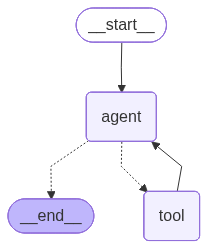

In [4]:
# 그래프 흐름: START → agent → {should_continue} → tool 또는 END
# agent 노드: LLM을 호출해 응답(또는 도구 호출)을 생성해요
# 조건부 엣지: tool_calls가 있으면 tool 노드로, 없으면 END로 분기해요
# tool 노드: 도구를 실행한 후 다시 agent로 돌아가요 (에이전트 루프)
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
# ---------------------------------------------------
# 기본 대화 실행 - 메시지 누적 확인
# ---------------------------------------------------
# thread_id: 동일한 ID는 같은 대화 세션이에요 (체크포인터의 핵심)
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

# 1번째 대화: 이름 소개
input_message = HumanMessage(content="안녕하세요! 제 이름은 철수입니다. 잘 부탁드립니다.")

# === 1번째 대화 ===
for event in app.stream({"messages": [input_message]}, config, stream_mode="values"):
    # stream_mode="values": 각 단계마다 전체 상태를 반환해요
    event["messages"][-1].pretty_print()

================================ Human Message =================================

안녕하세요! 제 이름은 철수입니다. 잘 부탁드립니다.
================================== Ai Message ==================================

안녕하세요, 철수님! 잘 부탁드립니다. 어떻게 도와드릴까요?


In [6]:
# ---------------------------------------------------
# 후속 대화 - 메시지가 계속 누적돼요
# ---------------------------------------------------
# 동일한 thread_id를 사용하면 이전 대화 내용을 기억해요
input_message = HumanMessage(content="제 이름이 뭐라고요?")

# === 2번째 대화 ===
for event in app.stream({"messages": [input_message]}, config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

제 이름이 뭐라고요?
================================== Ai Message ==================================

철수님의 이름은 "철수"입니다. 추가로 궁금한 점이 있으신가요?


In [7]:
# ---------------------------------------------------
# 현재 상태 확인 - 누적된 메시지 목록
# ---------------------------------------------------
# get_state()로 체크포인터에 저장된 모든 메시지를 조회해요
messages = app.get_state(config).values["messages"]

print(f"현재 저장된 메시지 수: {len(messages)}개")
# ========================================
for i, message in enumerate(messages):
    print(f"[{i}] ", end="")
    message.pretty_print()

현재 저장된 메시지 수: 4개
[0] ================================ Human Message =================================

안녕하세요! 제 이름은 철수입니다. 잘 부탁드립니다.
[1] ================================== Ai Message ==================================

안녕하세요, 철수님! 잘 부탁드립니다. 어떻게 도와드릴까요?
[2] ================================ Human Message =================================

제 이름이 뭐라고요?
[3] ================================== Ai Message ==================================

철수님의 이름은 "철수"입니다. 추가로 궁금한 점이 있으신가요?


## 2. 수동 메시지 삭제: update_state() + RemoveMessage

그래프 외부에서 특정 메시지를 직접 삭제하는 방법이에요. `update_state()`에 `RemoveMessage`를 전달하면 해당 ID의 메시지가 체크포인터에서 제거돼요.

> 💡 **실무 팁**: 수동 삭제는 **민감한 정보**가 담긴 메시지를 선택적으로 제거하거나, 대화 이력을 수동으로 정리할 때 유용해요. 특정 메시지를 정밀하게 타겟팅할 수 있다는 것이 자동 삭제와의 차이점이에요.

> ⚠️ **자주 하는 실수**: `RemoveMessage`에는 반드시 **메시지 ID**를 전달해야 해요. 인덱스 번호가 아니에요. `messages[0].id`처럼 메시지 객체에서 `.id` 속성을 꺼내야 해요.

In [8]:
# ---------------------------------------------------
# RemoveMessage를 사용한 수동 삭제
# ---------------------------------------------------
# RemoveMessage: langchain_core.messages에서 가져와요
from langchain_core.messages import RemoveMessage

# 삭제 전: 현재 메시지 목록 확인
messages = app.get_state(config).values["messages"]
print(f"삭제 전 메시지 수: {len(messages)}개")
print(f"삭제 대상 메시지 ID: {messages[0].id}")
print(f"삭제 대상 내용: {messages[0].content[:50]}...")
print()

# update_state()로 첫 번째 메시지를 삭제해요
# RemoveMessage(id=...)에 메시지 ID를 전달하면 해당 메시지가 제거돼요
app.update_state(
    config,
    {"messages": RemoveMessage(id=messages[0].id)}  # 인덱스 [0]의 메시지 삭제
)

# 첫 번째 메시지 삭제 완료

삭제 전 메시지 수: 4개
삭제 대상 메시지 ID: 0b292a88-4581-459f-8c29-22fedcd6d398
삭제 대상 내용: 안녕하세요! 제 이름은 철수입니다. 잘 부탁드립니다....



{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f147741-a399-6c48-8005-ea820a8adf4c'}}

In [9]:
# ---------------------------------------------------
# 삭제 결과 확인
# ---------------------------------------------------
# 삭제 후 메시지 목록을 다시 조회해요
messages_after = app.get_state(config).values["messages"]

print(f"삭제 후 메시지 수: {len(messages_after)}개")
# ========================================
for i, message in enumerate(messages_after):
    print(f"[{i}] ", end="")
    message.pretty_print()

삭제 후 메시지 수: 3개
[0] ================================== Ai Message ==================================

안녕하세요, 철수님! 잘 부탁드립니다. 어떻게 도와드릴까요?
[1] ================================ Human Message =================================

제 이름이 뭐라고요?
[2] ================================== Ai Message ==================================

철수님의 이름은 "철수"입니다. 추가로 궁금한 점이 있으신가요?


In [10]:
# ---------------------------------------------------
# 여러 메시지 동시 삭제
# ---------------------------------------------------
# 리스트로 전달하면 여러 메시지를 한 번에 삭제할 수 있어요
from langchain_core.messages import RemoveMessage

messages = app.get_state(config).values["messages"]
print(f"삭제 전 메시지 수: {len(messages)}개")

# 모든 메시지를 한 번에 삭제해요
app.update_state(
    config,
    {"messages": [RemoveMessage(id=m.id) for m in messages]}
)

messages_cleared = app.get_state(config).values["messages"]
print(f"삭제 후 메시지 수: {len(messages_cleared)}개")
# 모든 메시지가 삭제되었어요

삭제 전 메시지 수: 3개
삭제 후 메시지 수: 0개


## 3. 자동 메시지 삭제: delete_messages 노드

프로덕션 환경에서는 대화가 진행될수록 메시지가 계속 쌓여요. 이를 자동으로 관리하려면 그래프 안에 삭제 로직을 담은 노드를 추가해요.

핵심 전략: **에이전트가 최종 응답을 완료할 때마다** `delete_messages` 노드를 실행해 오래된 메시지를 정리해요.

### 자동 삭제 구현 핵심

```mermaid
flowchart LR
    A["agent 노드"] --> B{"should_continue"}
    B -->|"tool_calls 있음"| C["action 노드"]
    C --> A
    B -->|"tool_calls 없음<br/>(최종 응답 완료)"| D["delete_messages<br/>오래된 메시지 정리"]
    D --> E["END"]
    
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef delete fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    
    class A,C process
    class B decision
    class D delete
    class E process
```

> 🎯 **강의 포인트**: `should_continue` 함수에서 도구 호출이 없을 때 `END` 대신 `"delete_messages"`로 라우팅하는 것이 핵심이에요. 이렇게 하면 매 대화 턴이 끝날 때마다 메시지 정리가 자동으로 실행돼요.

> 💡 **실무 팁**: 메시지를 몇 개 유지할지는 태스크에 따라 달라요. 일반 대화는 5~10개면 충분하지만, 코드 리뷰 같은 긴 맥락이 필요한 태스크는 더 많이 유지해야 해요. 토큰 수 기반으로 관리하는 방법은 `07-Memory` 파트에서 배울 거예요.

In [11]:
# ---------------------------------------------------
# 자동 삭제 노드가 포함된 그래프 구성
# ---------------------------------------------------
from typing import Literal
from langchain_core.tools import tool
from langchain_core.messages import RemoveMessage, HumanMessage
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode

# 새로운 메모리 인스턴스 (이전 테스트와 분리)
memory2 = MemorySaver()


@tool
def search2(query: str) -> str:
    """Call to surf on the web."""
    return f"'{query}'에 대한 검색 결과: LangGraph는 상태 기반 멀티 에이전트 프레임워크예요."


tools2 = [search2]
tool_node2 = ToolNode(tools2)

model2 = init_chat_model("openai:gpt-4o-mini")
bound_model2 = model2.bind_tools(tools2)


def delete_messages(state: MessagesState):
    """최근 3개 메시지만 남기고 오래된 메시지를 삭제해요"""
    messages = state["messages"]
    # 메시지가 3개 초과인 경우에만 삭제 진행
    if len(messages) > 3:
        # 뒤에서 3개(messages[-3:])를 제외한 나머지를 삭제 대상으로 지정
        # messages[:-3]: 마지막 3개를 제외한 모든 메시지
        return {
            "messages": [RemoveMessage(id=m.id) for m in messages[:-3]]
        }
    # 3개 이하이면 아무것도 삭제하지 않아요
    return {}


def should_continue_v2(state: MessagesState) -> Literal["action", "delete_messages"]:
    """도구 호출 여부에 따라 action 또는 delete_messages로 분기해요"""
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        # 도구 호출 없음: 최종 응답 완료 → 메시지 정리로 이동
        return "delete_messages"
    # 도구 호출 있음: 도구 실행으로 이동
    return "action"


def call_model2(state: MessagesState):
    """LLM을 호출하고 응답을 상태에 추가해요"""
    response = bound_model2.invoke(state["messages"])
    return {"messages": response}


# 그래프 구성
workflow2 = StateGraph(MessagesState)

workflow2.add_node("agent", call_model2)       # LLM 호출 노드
workflow2.add_node("action", tool_node2)       # 도구 실행 노드
workflow2.add_node(delete_messages)            # 메시지 삭제 노드 (함수명이 노드명)

workflow2.add_edge(START, "agent")

# 조건부 분기: agent → action 또는 delete_messages
# 함수 반환값("action" 또는 "delete_messages")이 그대로 노드명으로 사용돼요
workflow2.add_conditional_edges("agent", should_continue_v2)

workflow2.add_edge("action", "agent")          # 도구 실행 후 다시 agent로
workflow2.add_edge("delete_messages", END)     # 메시지 정리 후 종료

# 체크포인터를 포함해 컴파일
app2 = workflow2.compile(checkpointer=memory2)

# 자동 삭제 노드가 포함된 그래프 구축 완료

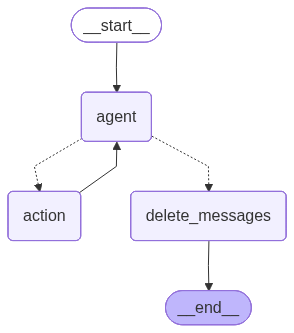

In [12]:
# 그래프 흐름: START → agent → {should_continue_v2} → action 또는 delete_messages → END
# agent 노드: LLM을 호출해 응답을 생성해요
# 조건부 엣지: tool_calls가 있으면 action(도구 실행)으로, 없으면 delete_messages로 가요
# delete_messages 노드: 최근 3개만 남기고 오래된 메시지를 자동 삭제해요
from IPython.display import Image, display

display(Image(app2.get_graph().draw_mermaid_png()))

## 4. 자동 삭제 동작 확인

실제로 대화를 여러 번 진행하면서 메시지가 어떻게 관리되는지 확인해볼게요. 매 대화 후 메시지 목록을 출력하면서 삭제 동작을 추적해요.

> 🔑 **핵심 개념**: 스트리밍 출력에서 메시지 수가 늘었다가 줄어드는 것을 볼 수 있어요. `delete_messages` 노드가 실행될 때 오래된 메시지가 상태에서 제거되는 순간을 직접 관찰할 수 있어요.

In [13]:
# ---------------------------------------------------
# 첫 번째 대화 - 메시지 2개 누적 예상
# ---------------------------------------------------
from langchain_core.messages import HumanMessage

# thread_id "2": 새로운 대화 세션
config2 = {"configurable": {"thread_id": "2"}}

input1 = HumanMessage(content="안녕하세요! 제 이름은 철수입니다. 잘 부탁드립니다.")

# === 1번째 대화 진행 중 ===
for event in app2.stream({"messages": [input1]}, config2, stream_mode="values"):
    # 각 이벤트마다 현재 메시지 타입과 내용을 간략히 출력해요
    print([(msg.type, msg.content[:30]) for msg in event["messages"]])

print()

# 1번째 대화 후 상태 확인
messages_after_1 = app2.get_state(config2).values["messages"]
print(f"1번째 대화 후 메시지 수: {len(messages_after_1)}개")
for m in messages_after_1:
    print(f"  [{m.type}] {m.content[:40]}")

[('human', '안녕하세요! 제 이름은 철수입니다. 잘 부탁드립니다.')]
[('human', '안녕하세요! 제 이름은 철수입니다. 잘 부탁드립니다.'), ('ai', '안녕하세요, 철수님! 잘 부탁드립니다. 무엇을 도와드릴')]

1번째 대화 후 메시지 수: 2개
  [human] 안녕하세요! 제 이름은 철수입니다. 잘 부탁드립니다.
  [ai] 안녕하세요, 철수님! 잘 부탁드립니다. 무엇을 도와드릴까요?


In [14]:
# ---------------------------------------------------
# 두 번째 대화 - delete_messages 노드 작동 확인
# ---------------------------------------------------
# 두 번째 대화가 끝나면 총 4개 메시지 → 3개 초과 → 오래된 1개 삭제
input2 = HumanMessage(content="제 이름이 뭐라고요?")

# === 2번째 대화 진행 중 ===
for event in app2.stream({"messages": [input2]}, config2, stream_mode="values"):
    print([(msg.type, msg.content[:30]) for msg in event["messages"]])

print()

# 2번째 대화 후 최종 상태 확인
messages_after_2 = app2.get_state(config2).values["messages"]
print(f"2번째 대화 후 메시지 수: {len(messages_after_2)}개 (최대 3개 유지)")
# ==================================================
for i, m in enumerate(messages_after_2):
    print(f"[{i}] [{m.type}] {m.content[:60]}")

[('human', '안녕하세요! 제 이름은 철수입니다. 잘 부탁드립니다.'), ('ai', '안녕하세요, 철수님! 잘 부탁드립니다. 무엇을 도와드릴'), ('human', '제 이름이 뭐라고요?')]
[('human', '안녕하세요! 제 이름은 철수입니다. 잘 부탁드립니다.'), ('ai', '안녕하세요, 철수님! 잘 부탁드립니다. 무엇을 도와드릴'), ('human', '제 이름이 뭐라고요?'), ('ai', '철수님이라고 하셨습니다. 맞나요?')]
[('ai', '안녕하세요, 철수님! 잘 부탁드립니다. 무엇을 도와드릴'), ('human', '제 이름이 뭐라고요?'), ('ai', '철수님이라고 하셨습니다. 맞나요?')]

2번째 대화 후 메시지 수: 3개 (최대 3개 유지)
[0] [ai] 안녕하세요, 철수님! 잘 부탁드립니다. 무엇을 도와드릴까요?
[1] [human] 제 이름이 뭐라고요?
[2] [ai] 철수님이라고 하셨습니다. 맞나요?


In [15]:
# ---------------------------------------------------
# 세 번째 대화 - 일관된 메시지 개수 유지 확인
# ---------------------------------------------------
# 세 번째 대화 후에도 최대 3개만 유지되어야 해요
input3 = HumanMessage(content="LangGraph에 대해 한 문장으로 설명해줘")

# === 3번째 대화 진행 중 ===
for event in app2.stream({"messages": [input3]}, config2, stream_mode="values"):
    print([(msg.type, msg.content[:30]) for msg in event["messages"]])

print()

# 3번째 대화 후 최종 상태
messages_after_3 = app2.get_state(config2).values["messages"]
print(f"3번째 대화 후 메시지 수: {len(messages_after_3)}개 (3개 유지됨)")
# ==================================================
for i, m in enumerate(messages_after_3):
    print(f"[{i}] [{m.type}] {m.content[:60]}")

[('ai', '안녕하세요, 철수님! 잘 부탁드립니다. 무엇을 도와드릴'), ('human', '제 이름이 뭐라고요?'), ('ai', '철수님이라고 하셨습니다. 맞나요?'), ('human', 'LangGraph에 대해 한 문장으로 설명해줘')]
[('ai', '안녕하세요, 철수님! 잘 부탁드립니다. 무엇을 도와드릴'), ('human', '제 이름이 뭐라고요?'), ('ai', '철수님이라고 하셨습니다. 맞나요?'), ('human', 'LangGraph에 대해 한 문장으로 설명해줘'), ('ai', '')]
[('ai', '안녕하세요, 철수님! 잘 부탁드립니다. 무엇을 도와드릴'), ('human', '제 이름이 뭐라고요?'), ('ai', '철수님이라고 하셨습니다. 맞나요?'), ('human', 'LangGraph에 대해 한 문장으로 설명해줘'), ('ai', ''), ('tool', "'LangGraph'에 대한 검색 결과: LangGra")]
[('ai', '안녕하세요, 철수님! 잘 부탁드립니다. 무엇을 도와드릴'), ('human', '제 이름이 뭐라고요?'), ('ai', '철수님이라고 하셨습니다. 맞나요?'), ('human', 'LangGraph에 대해 한 문장으로 설명해줘'), ('ai', ''), ('tool', "'LangGraph'에 대한 검색 결과: LangGra"), ('ai', 'LangGraph는 상태 기반 멀티 에이전트 프레임워크')]
[('ai', ''), ('tool', "'LangGraph'에 대한 검색 결과: LangGra"), ('ai', 'LangGraph는 상태 기반 멀티 에이전트 프레임워크')]

3번째 대화 후 메시지 수: 3개 (3개 유지됨)
[0] [ai] 
[1] [tool] 'LangGraph'에 대한 검색 결과: LangGraph는 상태 기반 멀티 에이전트 프레임워크예요.
[2] [ai] LangGraph는 상태 기반 멀티 에이전트 프레임워크입니다.


## 5. 삭제 임계값 커스터마이징

메시지 개수 임계값을 변경하면 얼마나 많은 대화 이력을 유지할지 조절할 수 있어요. 더 많은 이력을 유지할수록 LLM 응답의 맥락이 풍부해지지만 토큰 비용이 늘어요.

> 🎯 **강의 포인트**: `delete_messages` 함수에서 `messages[:-3]` 숫자를 바꾸면 유지 개수를 조절할 수 있어요. 숫자가 클수록 더 많은 이력을 유지해요. 예: `messages[:-5]`이면 최근 5개 유지.

In [16]:
# ============================================================
# TODO: 다른 임계값으로 자동 삭제 실험해보기
# 힌트: KEEP_LAST_N 숫자를 바꿔보세요
#       예: 최근 5개 유지 → KEEP_LAST_N = 5
#           최근 2개 유지 → KEEP_LAST_N = 2
# 예상 결과: 임계값이 크면 더 많은 대화 맥락이 유지돼요
# ============================================================

from langchain_core.messages import RemoveMessage, HumanMessage
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END
from typing import Literal

# 유지할 메시지 개수를 조절해보세요 (기본값: 3)
KEEP_LAST_N = 5  # TODO: 이 숫자를 바꿔서 실험해보세요!

memory3 = MemorySaver()
model3 = init_chat_model("openai:gpt-4o-mini")


def delete_messages_custom(state: MessagesState):
    """KEEP_LAST_N개의 최근 메시지만 유지해요"""
    messages = state["messages"]
    if len(messages) > KEEP_LAST_N:
        # messages[:-KEEP_LAST_N]: 마지막 KEEP_LAST_N개를 제외한 모든 메시지
        return {
            "messages": [RemoveMessage(id=m.id) for m in messages[:-KEEP_LAST_N]]
        }
    return {}


def should_continue_custom(state: MessagesState) -> Literal["delete_messages_custom"]:
    """항상 delete_messages_custom 노드로 이동해요 (도구 없는 단순 대화)"""
    return "delete_messages_custom"


def call_model_simple(state: MessagesState):
    # 도구 없이 순수 대화만 하는 버전이에요
    response = model3.invoke(state["messages"])
    return {"messages": response}


workflow3 = StateGraph(MessagesState)
workflow3.add_node("agent", call_model_simple)
workflow3.add_node(delete_messages_custom)  # 함수를 노드로 등록

workflow3.add_edge(START, "agent")
workflow3.add_conditional_edges(
    "agent",
    should_continue_custom,
    {"delete_messages_custom": "delete_messages_custom"}
)
workflow3.add_edge("delete_messages_custom", END)

app3 = workflow3.compile(checkpointer=memory3)

# 여러 번 대화해서 삭제 동작 관찰
config3 = {"configurable": {"thread_id": "custom-1"}}

questions = [
    "내 이름은 영희예요",
    "좋아하는 색깔은 파란색이에요",
    "취미는 독서예요",
    "내 이름이 뭐예요?",
    "좋아하는 색깔이 뭐예요?",
    "취미가 뭐예요?",
]

print(f"설정: 최근 {KEEP_LAST_N}개 메시지 유지")
# ==================================================

for i, q in enumerate(questions, 1):
    msg = HumanMessage(content=q)
    
    # 그래프 실행 (중간 출력 억제)
    for _ in app3.stream({"messages": [msg]}, config3, stream_mode="values"):
        pass
    
    # 각 대화 후 메시지 수 출력
    current_messages = app3.get_state(config3).values["messages"]
    print(f"{i}번째 대화 후: {len(current_messages)}개 메시지 유지")

print()
# === 최종 메시지 목록 ===
final_messages = app3.get_state(config3).values["messages"]
for i, m in enumerate(final_messages):
    print(f"[{i}] [{m.type}] {m.content[:50]}")

설정: 최근 5개 메시지 유지
1번째 대화 후: 2개 메시지 유지
2번째 대화 후: 4개 메시지 유지
3번째 대화 후: 5개 메시지 유지
4번째 대화 후: 5개 메시지 유지
5번째 대화 후: 5개 메시지 유지
6번째 대화 후: 5개 메시지 유지

[0] [ai] 당신의 이름은 영희입니다! 혹시 더 궁금한 점이나 이야기하고 싶은 것이 있다면 말씀해 주세
[1] [human] 좋아하는 색깔이 뭐예요?
[2] [ai] 저는 인공지능이라서 색깔에 대한 선호가 없지만, 많은 사람들이 파란색, 초록색, 그리고 빨
[3] [human] 취미가 뭐예요?
[4] [ai] 저는 인공지능이라 취미가 없지만, 사람들은 독서, 운동, 음악 감상, 요리, 여행 등 다양


## 6. RemoveMessage의 고급 활용: 조건부 삭제

단순히 오래된 메시지를 삭제하는 것 외에도, 메시지의 **타입**이나 **내용**에 따라 선택적으로 삭제할 수 있어요.

> 💡 **실무 팁**: 도구 호출 결과(`ToolMessage`)는 LLM이 응답을 생성한 후에는 더 이상 필요 없는 경우가 많아요. 도구 응답만 선택적으로 삭제하면 컨텍스트를 유지하면서도 토큰을 절약할 수 있어요.

> ⚠️ **자주 하는 실수**: 도구 호출 메시지(`AIMessage`의 `tool_calls`)와 도구 응답 메시지(`ToolMessage`)는 **쌍으로 유지**해야 해요. `ToolMessage`만 삭제하고 `AIMessage`(도구 호출 포함)를 남기면 LLM이 혼란스러워할 수 있어요.

In [17]:
# ---------------------------------------------------
# 타입별 선택적 삭제: ToolMessage 필터링
# ---------------------------------------------------
# 메시지 타입을 확인해 선택적으로 삭제하는 패턴을 살펴봐요
from langchain_core.messages import RemoveMessage, ToolMessage, HumanMessage, AIMessage


def delete_tool_messages_only(messages: list) -> list:
    """ToolMessage(도구 실행 결과)만 선택적으로 삭제 대상으로 반환해요"""
    # isinstance()로 메시지 타입을 확인해요
    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]
    return [RemoveMessage(id=m.id) for m in tool_messages]


# 테스트: 여러 타입의 메시지가 있는 상태 시뮬레이션
test_messages = [
    HumanMessage(content="LangGraph를 검색해줘", id="msg-1"),
    AIMessage(
        content="검색하겠습니다",
        id="msg-2",
        tool_calls=[{"name": "search", "args": {"query": "LangGraph"}, "id": "call-1", "type": "tool_call"}]
    ),
    ToolMessage(content="LangGraph 검색 결과: 상태 기반 에이전트 프레임워크", id="msg-3", tool_call_id="call-1"),
    AIMessage(content="LangGraph는 상태 기반 멀티 에이전트 프레임워크예요.", id="msg-4"),
]

# 전체 메시지 목록:
for m in test_messages:
    print(f"  [{m.type}] {m.content[:50]}")

# 삭제 대상 식별
to_delete = delete_tool_messages_only(test_messages)
print(f"\n삭제 대상 (ToolMessage): {len(to_delete)}개")
# 도구 응답만 제거하고 사람/AI 메시지는 보존해요

  [human] LangGraph를 검색해줘
  [ai] 검색하겠습니다
  [tool] LangGraph 검색 결과: 상태 기반 에이전트 프레임워크
  [ai] LangGraph는 상태 기반 멀티 에이전트 프레임워크예요.

삭제 대상 (ToolMessage): 1개


In [18]:
# ---------------------------------------------------
# 메시지 타입별 통계 확인 헬퍼
# ---------------------------------------------------
# 실제 앱에서 메시지 타입 분포를 확인할 때 유용해요
from collections import Counter


def analyze_messages(messages: list, title: str = "메시지 분석") -> None:
    """메시지 목록의 타입별 통계를 출력하는 헬퍼 함수예요"""
    type_counts = Counter(m.type for m in messages)
    # 총 내용 길이로 토큰 비용을 대략 예측해요
    total_content_len = sum(len(str(m.content)) for m in messages)
    
    print(f"\n=== {title} ===")
    print(f"총 메시지 수: {len(messages)}개")
    print(f"타입별 분포:")
    for msg_type, count in type_counts.items():
        print(f"  {msg_type}: {count}개")
    # 한 글자 약 2~3 토큰으로 추정해요 (한국어)
    estimated_tokens = total_content_len * 2
    print(f"총 내용 길이: {total_content_len}자 (약 {estimated_tokens} 토큰 추정)")


# 현재 app3 대화의 메시지 분석
final_messages = app3.get_state(config3).values["messages"]
analyze_messages(final_messages, "최종 메시지 상태")

print()
# 각 메시지 상세:
for i, m in enumerate(final_messages):
    print(f"[{i}] ID={m.id[:8]}... [{m.type}] {m.content[:50]}")


=== 최종 메시지 상태 ===
총 메시지 수: 5개
타입별 분포:
  ai: 3개
  human: 2개
총 내용 길이: 234자 (약 468 토큰 추정)

[0] ID=lc_run--... [ai] 당신의 이름은 영희입니다! 혹시 더 궁금한 점이나 이야기하고 싶은 것이 있다면 말씀해 주세
[1] ID=2b00b9c8... [human] 좋아하는 색깔이 뭐예요?
[2] ID=lc_run--... [ai] 저는 인공지능이라서 색깔에 대한 선호가 없지만, 많은 사람들이 파란색, 초록색, 그리고 빨
[3] ID=40245078... [human] 취미가 뭐예요?
[4] ID=lc_run--... [ai] 저는 인공지능이라 취미가 없지만, 사람들은 독서, 운동, 음악 감상, 요리, 여행 등 다양


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **`RemoveMessage`**: 메시지 ID를 지정해 상태에서 메시지를 제거하는 수정자예요. `add_messages` reducer가 이 신호를 처리해요. `langchain_core.messages`에서 임포트해요.
- **수동 삭제**: `update_state()` + `RemoveMessage(id=messages[0].id)` 패턴으로 외부에서 특정 메시지를 정밀하게 삭제해요.
- **자동 삭제**: `delete_messages` 노드를 그래프에 추가하고, `should_continue`에서 최종 응답 후 이 노드로 라우팅해요.
- **임계값 조절**: `messages[:-N]`에서 N을 바꿔 유지할 메시지 개수를 조절해요. 클수록 더 많은 맥락을 유지하지만 토큰 비용이 늘어요.
- **타입별 삭제**: `isinstance(m, ToolMessage)`처럼 메시지 타입을 확인해 선택적으로 삭제할 수 있어요.


## 다음 노트북 예고

다음 `06-Conversation-Summary.ipynb`에서는 **대화 요약 패턴**을 배워요. 메시지를 단순 삭제하면 맥락 손실이 생기는 문제를, LLM으로 오래된 대화를 **증분 요약(incremental summary)**해서 정보를 보존하면서도 토큰을 절약하는 방식으로 해결해요. 삭제와 요약을 조합하면 무한 대화도 실용적인 비용으로 운영할 수 있어요.